In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import joblib
from rss import preprocess, features

# Paths
CUSTOM_DIR = Path.cwd() # Update with actual path to project directory
DATA_DIR = CUSTOM_DIR / 'data'
SC_DIR = DATA_DIR / 'sleep-cassette'
MODEL_DIR = CUSTOM_DIR / 'checkpoints/model/RF'

# Load pairs
def discover_pairs(root_dir):
    psgs = sorted(Path(root_dir).glob('*-PSG.edf'))
    pairs = []
    for psg in psgs:
        subject_id = psg.name[:6]
        hyp_files = list(Path(root_dir).glob(f'{subject_id}*-Hypnogram.edf'))
        if hyp_files:
            pairs.append((psg, hyp_files[0]))
    return pairs

sc_pairs = discover_pairs(SC_DIR)

# Load model
model_path = MODEL_DIR / 'random_forest_sc.pkl'
clf = joblib.load(model_path)

print('Model loaded!')
print('SC pairs found:', len(sc_pairs))

Model loaded!
SC pairs found: 153


In [2]:
# Load example subject
example_psg, example_hyp = sc_pairs[0]

# Load epochs and labels
X_epochs, y_true, sfreq = preprocess.load_subject_epochs(
    example_psg, example_hyp, preprocess.COMMON_CHANNELS, verbose=False
)

# Extract features - same as training!
X_features, freqs = features.extract_psd_features(X_epochs[:, :3, :], sfreq, verbose=False)
n_epochs = X_epochs.shape[0]
psds_3d = X_features.reshape(n_epochs, 3, -1)
psds_binned, bin_freqs = features.bin_psd(psds_3d, freqs, bin_width=0.5, fmin=0.5, fmax=40.0)
X_features_binned = psds_binned.reshape(n_epochs, -1)

X_emg_features, _ = features.extract_emg_features(X_epochs[:, 3, :])
X_combined = np.hstack([X_features_binned, X_emg_features])

print(X_combined.shape)  # should be (n_epochs, 246)

c:\Users\E1024679\Documents\RobustSleepStaging\rss\preprocess.py:34: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
c:\Users\E1024679\Documents\RobustSleepStaging\rss\preprocess.py:34: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
c:\Users\E1024679\Documents\RobustSleepStaging\rss\preprocess.py:34: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
c:\Users\E1024679\Documents\RobustSleepStaging\rss\preprocess.py:83: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations)


(1689, 246)


[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.0s finished


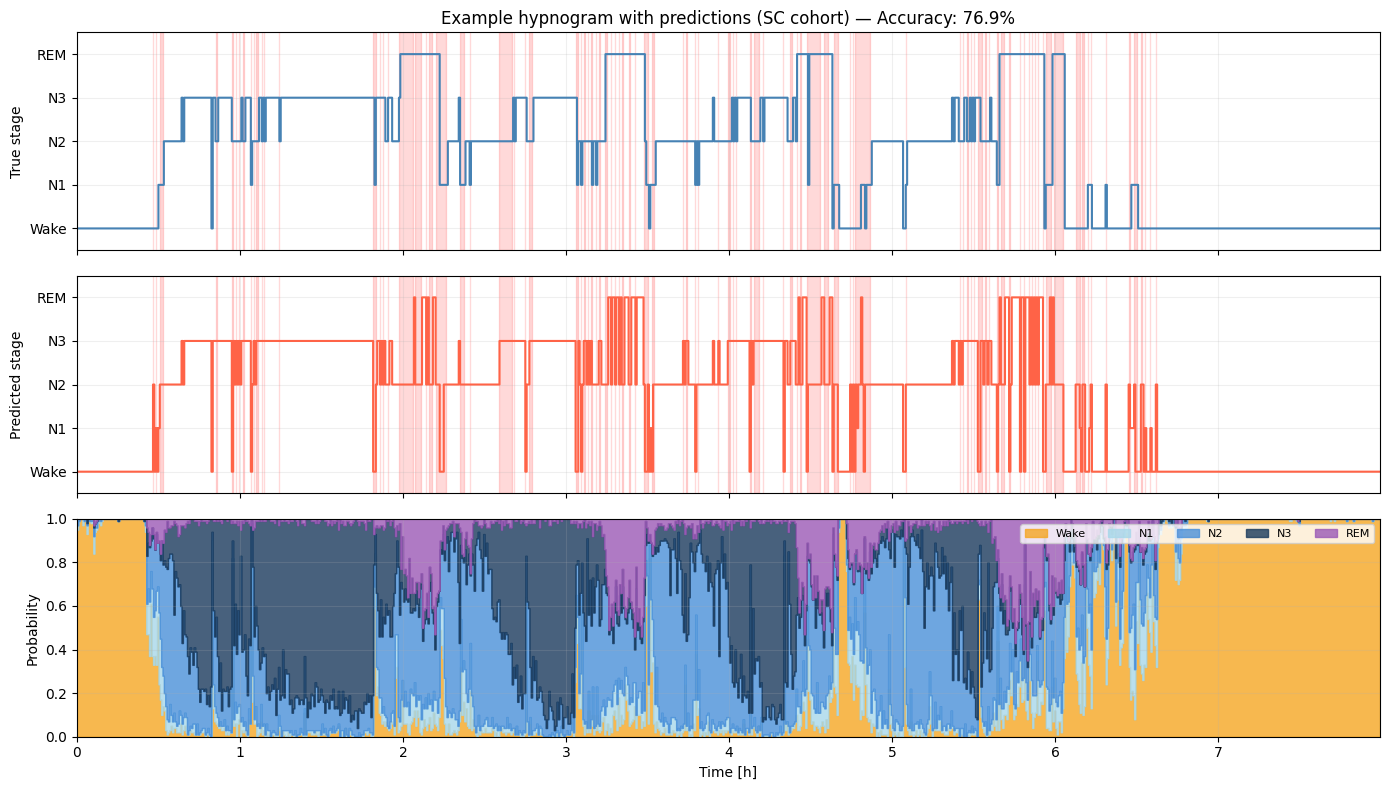

In [3]:
# Make predictions + probabilities
y_pred = clf.predict(X_combined)
y_proba = clf.predict_proba(X_combined)

# Crop
last_sleep = np.where(y_true != 0)[0][-1]
cutoff = last_sleep + 180
y_true_crop = y_true[:cutoff]
y_pred_crop = y_pred[:cutoff]
y_proba_crop = y_proba[:cutoff]
times_hours = np.arange(cutoff) * 30 / 3600

accuracy = np.mean(y_true_crop == y_pred_crop)
correct = (y_true_crop == y_pred_crop).astype(int)

stage_colors_proba = {
    0: '#f5a623',   # Wake - orange
    1: '#a8d8ea',   # N1 - light blue
    2: '#4a90d9',   # N2 - blue
    3: '#1a3a5c',   # N3 - dark blue
    4: '#9b59b6',   # REM - purple
}

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)




# ── Row 1: Ground Truth ──────────────────────────────────────────────
axes[0].fill_between(times_hours, -0.5, 4.5, 
                     where=correct==0, step='post',
                     color='red', alpha=0.15, label='Incorrect')
axes[0].step(times_hours, y_true_crop, where='post', color='steelblue', lw=1.5)
axes[0].set_yticks(list(preprocess.STAGE_NAMES.keys()))
axes[0].set_yticklabels(list(preprocess.STAGE_NAMES.values()))
axes[0].set_ylabel("True stage")
axes[0].set_title(f"Example hypnogram with predictions (SC cohort) — Accuracy: {accuracy:.1%}")
axes[0].grid(alpha=0.2)
axes[0].margins(x=0)
axes[0].set_ylim(-0.5, 4.5)





# ── Row 2: Predictions ───────────────────────────────────────────────
axes[1].fill_between(times_hours, -0.5, 4.5,
                     where=correct==0, step='post',
                     color='red', alpha=0.15)
axes[1].step(times_hours, y_pred_crop, where='post', color='tomato', lw=1.5)
axes[1].set_yticks(list(preprocess.STAGE_NAMES.keys()))
axes[1].set_yticklabels(list(preprocess.STAGE_NAMES.values()))
axes[1].set_ylabel("Predicted stage")
axes[1].grid(alpha=0.2)
axes[1].margins(x=0)
axes[1].set_ylim(-0.5, 4.5)




# ── Row 3: Prediction Probabilities ─────────────────────────────────
classes = clf.classes_
bottom = np.zeros(len(times_hours))
for i, stage in enumerate(classes):
    color = stage_colors_proba.get(stage, '#cccccc')
    stage_name = preprocess.STAGE_NAMES.get(int(stage), f"Stage {stage}")
    axes[2].fill_between(times_hours, bottom, bottom + y_proba_crop[:, i],
                         step='post', color=color, alpha=0.8, label=stage_name)
    bottom += y_proba_crop[:, i]

axes[2].set_ylabel("Probability")
axes[2].set_ylim(0, 1)
axes[2].legend(loc='upper right', ncol=5, fontsize=8)
axes[2].grid(alpha=0.2)
axes[2].margins(x=0)
axes[2].set_xlabel("Time [h]")

plt.tight_layout()
plt.savefig('hypnogram_final.png', dpi=150, bbox_inches='tight')
plt.show()